<a href="https://colab.research.google.com/github/Supriya-Burla/INFOSYS-_INTERNSHIP-OIL_SPILL_DETECTION-/blob/supriya-burla/oil_spill_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Data Access and Setup

### Mounting Google Drive

- We mount Google Drive to access datasets and project files stored there.
- This allows Colab to read/write files directly from your Drive.
- Purpose: Enables loading training, validation, and test datasets into the notebook.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Setting Up Data Directory and Inspecting Files

- Define the path to the project dataset stored in Google Drive.
- Use `os.walk` to iterate through the folder and count the number of files in each subdirectory.
- Purpose: Verify that the dataset is correctly stored and accessible, and get an overview of the data available for training, validation, and testing.


In [ ]:
import os

# Example path (adjust it to your actual folder location)
data_dir = "/content/drive/MyDrive/oil_spill_detection"

# Check files
for root, dirs, files in os.walk(data_dir):
    print(root, "->", len(files), "files")


/content/drive/MyDrive/oil_spill_detection -> 2 files
/content/drive/MyDrive/oil_spill_detection/train -> 0 files
/content/drive/MyDrive/oil_spill_detection/train/masks -> 811 files
/content/drive/MyDrive/oil_spill_detection/train/images -> 811 files
/content/drive/MyDrive/oil_spill_detection/test -> 0 files
/content/drive/MyDrive/oil_spill_detection/test/images -> 254 files
/content/drive/MyDrive/oil_spill_detection/test/masks -> 254 files
/content/drive/MyDrive/oil_spill_detection/val -> 0 files
/content/drive/MyDrive/oil_spill_detection/val/masks -> 203 files
/content/drive/MyDrive/oil_spill_detection/val/images -> 203 files
/content/drive/MyDrive/oil_spill_detection/models -> 2 files


### Visualizing Random Sample from Training Dataset

- Select a random image and its corresponding mask from the training dataset.
- Read the image using OpenCV and convert it from BGR to RGB for proper display.
- Read the mask as a grayscale image since it represents binary segmentation (oil spill vs background).
- Use Matplotlib to display the **satellite image** alongside its **oil spill mask**.
- Purpose: Quickly inspect the dataset to ensure images and masks are correctly aligned and readable.


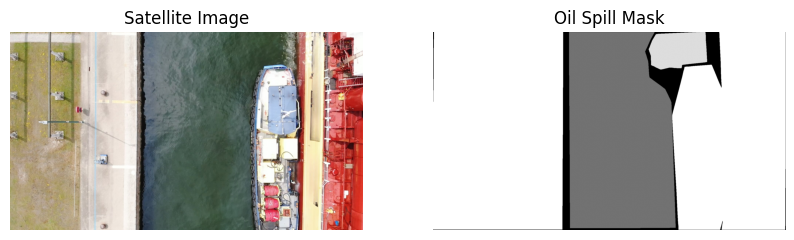

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os

# Example: pick a random image from train dataset
images_dir = "/content/drive/MyDrive/oil_spill_detection/train/images"
masks_dir  = "/content/drive/MyDrive/oil_spill_detection/train/masks"

image_files = sorted(os.listdir(images_dir))
mask_files  = sorted(os.listdir(masks_dir))

# Random sample
idx = random.randint(0, len(image_files)-1)
img_path  = os.path.join(images_dir, image_files[idx])
mask_path = os.path.join(masks_dir, mask_files[idx])

# Read image and mask
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, 0)  # grayscale mask

# Plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Oil Spill Mask")
plt.axis("off")
plt.show()


### Visualizing Pixel Intensity Distribution

- Convert the selected RGB image to grayscale to analyze intensity values.
- Plot a histogram of pixel intensities using Matplotlib.
- Purpose: Understand the distribution of pixel values in the image, which helps in preprocessing decisions such as normalization or contrast adjustment.


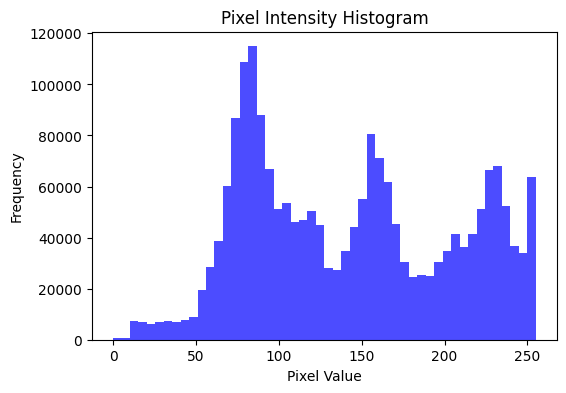

In [ ]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(6,4))
plt.hist(gray_img.ravel(), bins=50, color='blue', alpha=0.7)
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


### Image Statistics

- Convert the RGB image to grayscale to calculate statistical measures.
- Compute and print the **mean, standard deviation, minimum, and maximum** pixel values.
- Purpose: Provides insights into image brightness, contrast, and dynamic range, which can guide preprocessing and normalization steps for training.


In [ ]:
import numpy as np
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Mean:", np.mean(gray_img), "Std:", np.std(gray_img),
      "Min:", np.min(gray_img), "Max:", np.max(gray_img))


Mean: 138.24107783564816 Std: 62.07486586408615 Min: 0 Max: 255


### Preprocessing Images and Masks

- Define a function `preprocess_image` to prepare images and masks for training.
- **Images**:  
  - Read from file, decode PNG, resize to 256x256, and normalize pixel values to 0-1.
- **Masks**:  
  - Read from file, decode PNG, resize using nearest-neighbor to preserve labels, and convert to binary (0 or 1).
- Purpose: Ensures that input images and masks have consistent size and format, ready for the model training pipeline.


In [ ]:
import tensorflow as tf

IMG_SIZE = (256, 256)

def preprocess_image(img_path, mask_path):
    # Load image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # normalize to 0-1

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask > 0, tf.float32)  # binary mask

    return img, mask


### Data Augmentation Function

- Define a function `augment` to apply random transformations to images and masks during training.
- **Augmentation techniques include**:  
  - Horizontal and vertical flips.  
  - Rotation by 0°, 90°, 180°, or 270°.  
  - Random brightness and contrast adjustments.  
  - Random zoom by cropping and resizing the image and mask.  
- Purpose: Increases dataset variability, helping the model generalize better and preventing overfitting.


In [ ]:
import tensorflow as tf

def augment(img, mask):
    # --- Random horizontal flip ---
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # --- Random vertical flip ---
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # --- Random rotation (0°, 90°, 180°, 270°) ---
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    # --- Random brightness adjustment ---
    img = tf.image.random_brightness(img, max_delta=0.2)  # delta=0.2 means +/-20% brightness

    # --- Random contrast adjustment ---
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)  # adjust contrast by 0.8-1.2x

    # --- Random zoom ---
    # Randomly crop 80-100% of the image and resize back to original
    scale = tf.random.uniform([], 0.8, 1.0)
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    new_h, new_w = tf.cast(scale * tf.cast(h, tf.float32), tf.int32), tf.cast(scale * tf.cast(w, tf.float32), tf.int32)

    img = tf.image.random_crop(img, size=[new_h, new_w, 3])
    mask = tf.image.random_crop(mask, size=[new_h, new_w, 1])

    img = tf.image.resize(img, [h, w])
    mask = tf.image.resize(mask, [h, w], method='nearest')

    return img, mask


### Creating Dataset Pipelines

1. **Load and Match Paths**  
- Define directories for training, validation, and test images and masks.  
- Use the `load_paths` function to align images and masks by filename.  
- Print dataset sizes to verify correct loading.

2. **Define Dataset Pipeline**  
- Use `tf.data.Dataset` to efficiently load, preprocess, and batch images and masks.  
- Apply `preprocess_image` to resize and normalize images and convert masks to binary.  
- Apply `augment` for training data to increase variability.  
- Shuffle training data and batch datasets for efficient GPU usage.  
- Prefetch to improve performance during training.

3. **Create Datasets**  
- `train_dataset`: used for model training with augmentation and shuffling.  
- `val_dataset`: used for validation without augmentation or shuffling.  
- `test_dataset`: used for final evaluation without augmentation or shuffling.

✅ Purpose: Prepares the data for model training, validation, and testing in an efficient and reproducible pipeline.



In [ ]:
import glob

# Function to load and match paths
def load_paths(img_dir, mask_dir):
    img_paths = sorted(glob.glob(img_dir + "/*.*"))
    mask_paths = sorted(glob.glob(mask_dir + "/*.*"))

    # Match by filename
    def base(fn): return os.path.splitext(os.path.basename(fn))[0]
    img_map = {base(f): f for f in img_paths}
    mask_map = {base(f): f for f in mask_paths}

    common_keys = list(set(img_map.keys()) & set(mask_map.keys()))
    img_paths = [img_map[k] for k in common_keys]
    mask_paths = [mask_map[k] for k in common_keys]

    return img_paths, mask_paths

# Paths
TRAIN_IMG_DIR = "/content/drive/MyDrive/oil_spill_detection/train/images"
TRAIN_MASK_DIR = "/content/drive/MyDrive/oil_spill_detection/train/masks"
VAL_IMG_DIR   = "/content/drive/MyDrive/oil_spill_detection/val/images"
VAL_MASK_DIR  = "/content/drive/MyDrive/oil_spill_detection/val/masks"
TEST_IMG_DIR  = "/content/drive/MyDrive/oil_spill_detection/test/images"
TEST_MASK_DIR = "/content/drive/MyDrive/oil_spill_detection/test/masks"

train_img, train_mask = load_paths(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_img, val_mask     = load_paths(VAL_IMG_DIR, VAL_MASK_DIR)
test_img, test_mask   = load_paths(TEST_IMG_DIR, TEST_MASK_DIR)

print("Train:", len(train_img), "Val:", len(val_img), "Test:", len(test_img))

# Dataset pipeline
BATCH_SIZE = 8

def make_dataset(img_list, mask_list, batch_size=BATCH_SIZE, shuffle=True, augment_data=True):
    dataset = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=100, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_img, train_mask)
val_dataset   = make_dataset(val_img, val_mask, shuffle=False, augment_data=False)
test_dataset  = make_dataset(test_img, test_mask, shuffle=False, augment_data=False)

print("✅ Datasets ready for training!")


Train: 811 Val: 203 Test: 254
✅ Datasets ready for training!


### Visualizing a Batch of Images and Masks

- Define a function `visualize_batch` to display multiple images and their corresponding masks from a dataset batch.
- Plots **satellite images** on the top row and their **oil spill masks** on the bottom row.
- Purpose: Quickly inspect a batch of data to ensure that preprocessing, augmentation, and dataset pipeline are working correctly.
- Helps verify that images and masks are properly aligned and ready for training.


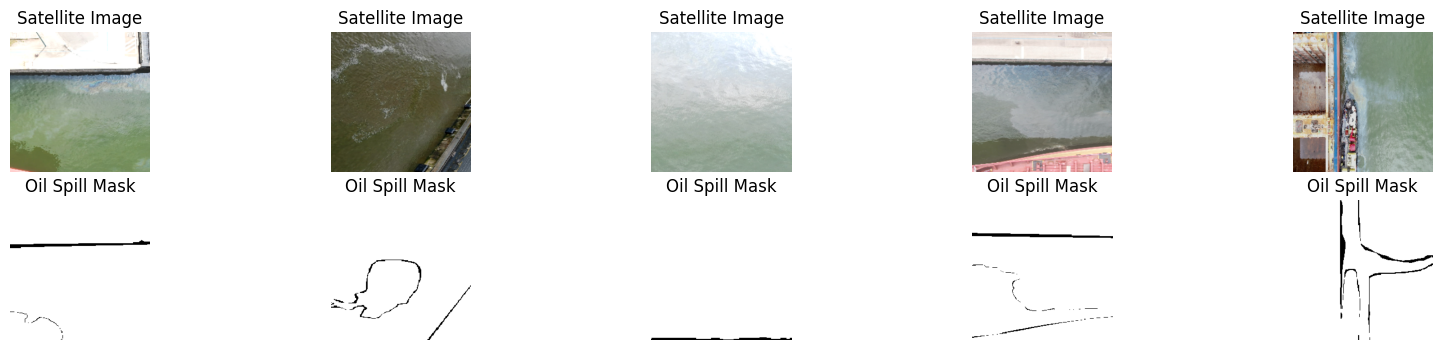

In [ ]:
def visualize_batch(dataset, num_samples=5):
    for img_batch, mask_batch in dataset.take(1):
        plt.figure(figsize=(num_samples*4, 4))
        for i in range(num_samples):
            img = img_batch[i].numpy()
            mask = mask_batch[i].numpy().squeeze()
            plt.subplot(2, num_samples, i+1)
            plt.imshow(img)
            plt.title("Satellite Image")
            plt.axis("off")
            plt.subplot(2, num_samples, num_samples+i+1)
            plt.imshow(mask, cmap="gray")
            plt.title("Oil Spill Mask")
            plt.axis("off")
        plt.show()

# ✅ Run visualization
visualize_batch(train_dataset, num_samples=5)

##  Model Development


## Imports

- Import libraries required for building and training the deep learning model:
  - `tensorflow` and `keras` for model creation and training.
  - `backend as K` for defining custom metrics and loss functions.
  - `matplotlib.pyplot` for visualization of results and predictions.
  - `numpy` for numerical operations and array handling.
  - `skimage.morphology` for post-processing predicted masks.
  - `preprocess_input` from MobileNetV2 to normalize images for transfer learning.
- Purpose: Sets up all necessary tools for model building, training, and evaluation.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import matplotlib.pyplot as plt
import numpy as np
from skimage import morphology
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

### Preprocessing Function

We define a function `preprocess_for_model` to:

- Normalize input images using MobileNetV2 preprocessing.
- Ensure masks are in float32 format for training.
- Purpose: Prepare images and masks so they are compatible with the model architecture.


In [24]:
def preprocess_for_model(img, mask):
    img = preprocess_input(img)  # MobileNetV2 compatible normalization
    return img, mask


Build U-Net

### U-Net Model Construction

- We build a U-Net segmentation model using MobileNetV2 as the encoder.
- Skip connections from the encoder to the decoder help preserve spatial details.
- The decoder upsamples features to reconstruct the binary oil spill mask.
- Encoder layers are initially frozen to leverage transfer learning.
- The output layer uses sigmoid activation to predict oil spill regions (0 or 1).


In [ ]:
def build_unet(input_size=(256,256,3)):
    """
    Returns a U-Net model with MobileNetV2 as encoder and custom decoder.
    Encoder is frozen initially for transfer learning.
    """
    # Pretrained MobileNetV2 as encoder
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_size, include_top=False, weights="imagenet"
    )

    # Encoder skip connections
    skips = [
        base_model.get_layer("block_1_expand_relu").output,   # 128x128
        base_model.get_layer("block_3_expand_relu").output,   # 64x64
        base_model.get_layer("block_6_expand_relu").output,   # 32x32
        base_model.get_layer("block_13_expand_relu").output,  # 16x16
    ]
    encoder_output = base_model.get_layer("block_16_project").output  # 8x8

    # Decoder: Upsample and combine with skip connections
    x = encoder_output
    decoder_filters = [512, 256, 128, 64]
    for i, skip in enumerate(reversed(skips)):
        x = layers.Conv2DTranspose(decoder_filters[i], (3,3), strides=2, padding="same")(x)
        x = layers.concatenate([x, skip])
        x = layers.Conv2D(decoder_filters[i], (3,3), activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(decoder_filters[i], (3,3), activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)

    # Final upsample to match input size (256x256x1)
    x = layers.Conv2DTranspose(32, (3,3), strides=2, padding="same")(x)
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(1, (1,1), activation="sigmoid")(x)

    # Create model
    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Freeze encoder layers initially
    for layer in base_model.layers:
        layer.trainable = False

    return model

# 4️⃣ Instantiate and summarize model
model = build_unet(input_size=(256,256,3))
model.summary()

/tmp/ipython-input-2610354362.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 14,487,905 (55.27 MB)

 Trainable params: 12,642,017 (48.23 MB)

 Non-trainable params: 1,845,888 (7.04 MB)

## Training and Evaluation - Metrics & Loss

We define metrics and loss functions:

- **Dice Coefficient** and **IoU**: Measure overlap between predicted masks and ground truth.
- **Dice Loss + IoU Loss + Binary Cross-Entropy**: Combined into `combined_loss` to guide training.
- **Precision, Recall, F1-Score**: Evaluate prediction quality beyond accuracy.
- Purpose: Ensure the model learns both pixel-wise accuracy and region-level segmentation.
### Model Compilation

- Compiled using Adam optimizer and combined loss function.
- Metrics include accuracy, Dice, IoU, precision, recall, and F1-score.
- Purpose: Prepares the model for training and evaluation.


In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

In [31]:
# -----------------------------
# 1. Metrics & Loss Functions
# -----------------------------
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_loss(y_true, y_pred):
    return 1 - iou_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    """Binary Crossentropy + Dice + IoU Loss"""
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred) + iou_loss(y_true, y_pred)

def precision_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.round(y_true * y_pred))
    fp = K.sum(K.round((1 - y_true) * y_pred))
    return tp / (tp + fp + K.epsilon())

def recall_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.round(y_true * y_pred))
    fn = K.sum(K.round(y_true * (1 - y_pred)))
    return tp / (tp + fn + K.epsilon())

def f1_score(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

# -----------------------------
# 3. Model Compilation
# -----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=["accuracy", dice_coefficient, iou_coefficient, precision_m, recall_m, f1_score]
)


### Callbacks for Efficient Training

- **ModelCheckpoint**: Saves the best model based on validation loss.
- **EarlyStopping**: Stops training if validation loss does not improve to prevent overfitting.
- **ReduceLROnPlateau**: Reduces learning rate when the model reaches a plateau in validation loss.


In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

### Dataset Inspection

- Prints the shape and data type of a batch of images and masks.
- Purpose: Verify that the dataset is loaded correctly and compatible with the model.


In [ ]:
for x, y in train_dataset.take(1):
    print("Image batch:", x.shape, x.dtype)
    print("Mask batch:", y.shape, y.dtype)

Image batch: (8, 256, 256, 3) <dtype: 'float32'>
Mask batch: (8, 256, 256, 1) <dtype: 'float32'>


 Training

### Model Training

- Trains the model on the training dataset with validation on the validation dataset.
- Uses callbacks for efficient training and to avoid overfitting.
- Purpose: Teach the model to accurately predict oil spill regions.


In [38]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 81s 532ms/step - accuracy: 0.9608 - dice_coefficient: 0.9587 - f1_score: 0.9797 - iou_coefficient: 0.9210 - loss: 0.2629 - precision_m: 0.9610 - recall_m: 0.9997 - val_accuracy: 0.9601 - val_dice_coefficient: 0.9653 - val_f1_score: 0.9796 - val_iou_coefficient: 0.9333 - val_loss: 0.2333 - val_precision_m: 0.9604 - val_recall_m: 0.9999 - learning_rate: 1.0000e-04
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 369ms/step - accuracy: 0.9610 - dice_coefficient: 0.9631 - f1_score: 0.9799 - iou_coefficient: 0.9292 - loss: 0.2488 - precision_m: 0.9615 - recall_m: 0.9995 - val_accuracy: 0.9633 - val_dice_coefficient: 0.9600 - val_f1_score: 0.9811 - val_iou_coefficient: 0.9233 - val_loss: 0.2415 - val_precision_m: 0.9665 - val_recall_m: 0.9964 - learning_rate: 1.0000e-04
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 86s 400ms/step - accuracy: 0.9589 - dice_coefficient: 0.9639 - f1_score: 0.9787 - iou_coefficient: 0.9307 - loss: 0.2511 - precision_m: 0.9595 - recal

102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 376ms/step - accuracy: 0.9615 - dice_coefficient: 0.9690 - f1_score: 0.9802 - iou_coefficient: 0.9402 - loss: 0.2291 - precision_m: 0.9623 - recall_m: 0.9991 - val_accuracy: 0.9614 - val_dice_coefficient: 0.9748 - val_f1_score: 0.9801 - val_iou_coefficient: 0.9511 - val_loss: 0.2053 - val_precision_m: 0.9619 - val_recall_m: 0.9995 - learning_rate: 1.0000e-04
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9613 - dice_coefficient: 0.9695 - f1_score: 0.9800 - iou_coefficient: 0.9411 - loss: 0.2293 - precision_m: 0.9621 - recall_m: 0.9990

102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 377ms/step - accuracy: 0.9613 - dice_coefficient: 0.9695 - f1_score: 0.9800 - iou_coefficient: 0.9411 - loss: 0.2293 - precision_m: 0.9621 - recall_m: 0.9990 - val_accuracy: 0.9640 - val_dice_coefficient: 0.9746 - val_f1_score: 0.9814 - val_iou_coefficient: 0.9506 - val_loss: 0.1996 - val_precision_m: 0.9675 - val_recall_m: 0.9960 - learning_rate: 1.0000e-04
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 80s 362ms/step - accuracy: 0.9607 - dice_coefficient: 0.9691 - f1_score: 0.9797 - iou_coefficient: 0.9404 - loss: 0.2318 - precision_m: 0.9613 - recall_m: 0.9993 - val_accuracy: 0.9629 - val_dice_coefficient: 0.9698 - val_f1_score: 0.9809 - val_iou_coefficient: 0.9415 - val_loss: 0.2115 - val_precision_m: 0.9656 - val_recall_m: 0.9968 - learning_rate: 1.0000e-04
Epoch 9/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 40s 364ms/step - accuracy: 0.9622 - dice_coefficient: 0.9709 - f1_score: 0.9806 - iou_coefficient: 0.9436 - loss: 0.2197 - precision_m: 0.9630 - recall_m: 0.9991

102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 374ms/step - accuracy: 0.9625 - dice_coefficient: 0.9717 - f1_score: 0.9807 - iou_coefficient: 0.9452 - loss: 0.2148 - precision_m: 0.9630 - recall_m: 0.9994 - val_accuracy: 0.9646 - val_dice_coefficient: 0.9725 - val_f1_score: 0.9818 - val_iou_coefficient: 0.9467 - val_loss: 0.1973 - val_precision_m: 0.9696 - val_recall_m: 0.9944 - learning_rate: 2.5000e-05
Epoch 15/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 369ms/step - accuracy: 0.9607 - dice_coefficient: 0.9712 - f1_score: 0.9797 - iou_coefficient: 0.9443 - loss: 0.2202 - precision_m: 0.9620 - recall_m: 0.9985 - val_accuracy: 0.9616 - val_dice_coefficient: 0.9615 - val_f1_score: 0.9802 - val_iou_coefficient: 0.9261 - val_loss: 0.2430 - val_precision_m: 0.9711 - val_recall_m: 0.9897 - learning_rate: 2.5000e-05
Epoch 16/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 367ms/step - accuracy: 0.9576 - dice_coefficient: 0.9694 - f1_score: 0.9781 - iou_coefficient: 0.9408 - loss: 0.2341 - precision_m: 0.9585 - recall_m: 0.99

### Training Curves

- Plots loss, accuracy, Dice, and IoU for both training and validation datasets.
- Purpose: Visualize how the model learns over epochs and detect overfitting or underfitting.


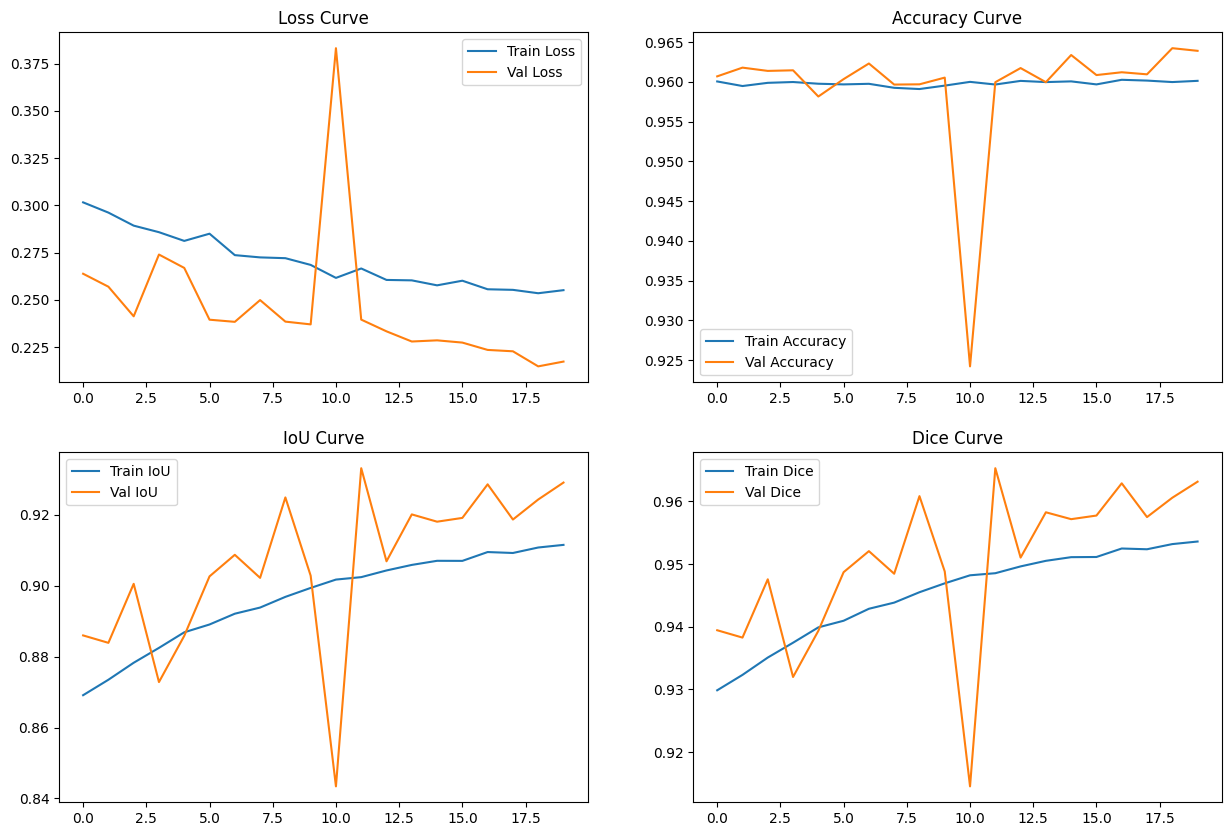

In [32]:
# ==========================
# Training Curves (Accuracy, Loss, IoU, Dice, F1)
# ==========================
plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy
plt.subplot(2,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.legend()

# IoU
plt.subplot(2,2,3)
plt.plot(history.history["iou_coefficient"], label="Train IoU")
plt.plot(history.history["val_iou_coefficient"], label="Val IoU")
plt.title("IoU Curve")
plt.legend()

# Dice
plt.subplot(2,2,4)
plt.plot(history.history["dice_coefficient"], label="Train Dice")
plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
plt.title("Dice Curve")
plt.legend()

plt.show()


Post-Processing

### Post-Processing Predicted Masks

- Apply thresholding and morphological operations (opening & closing) to clean predicted masks.
- Purpose: Remove small artifacts and refine predicted oil spill regions for better accuracy.


In [33]:
import cv2
def postprocess_mask(mask):
    mask = (mask > 0.5).astype('uint8')
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

### Model Evaluation on Test Data

- Uses `model.evaluate` to calculate metrics like loss, accuracy, Dice, IoU, precision, recall, and F1-score on unseen test data.
- Purpose: Quantitatively measure the performance of the trained model.


In [39]:
results = model.evaluate(test_dataset)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step - accuracy: 0.9629 - dice_coefficient: 0.9706 - f1_score: 0.9808 - iou_coefficient: 0.9431 - loss: 0.2104 - precision_m: 0.9680 - recall_m: 0.9940
loss: 0.2147
compile_metrics: 0.9621


### Visualization of Predictions

- Shows **original image**, **ground truth mask**, and **predicted mask overlayed** on the image.
- Red overlay represents predicted oil spill regions.
- Post-processing is applied to clean the mask before overlay.
- Purpose: Visually assess the model’s predictions and communicate results effectively.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


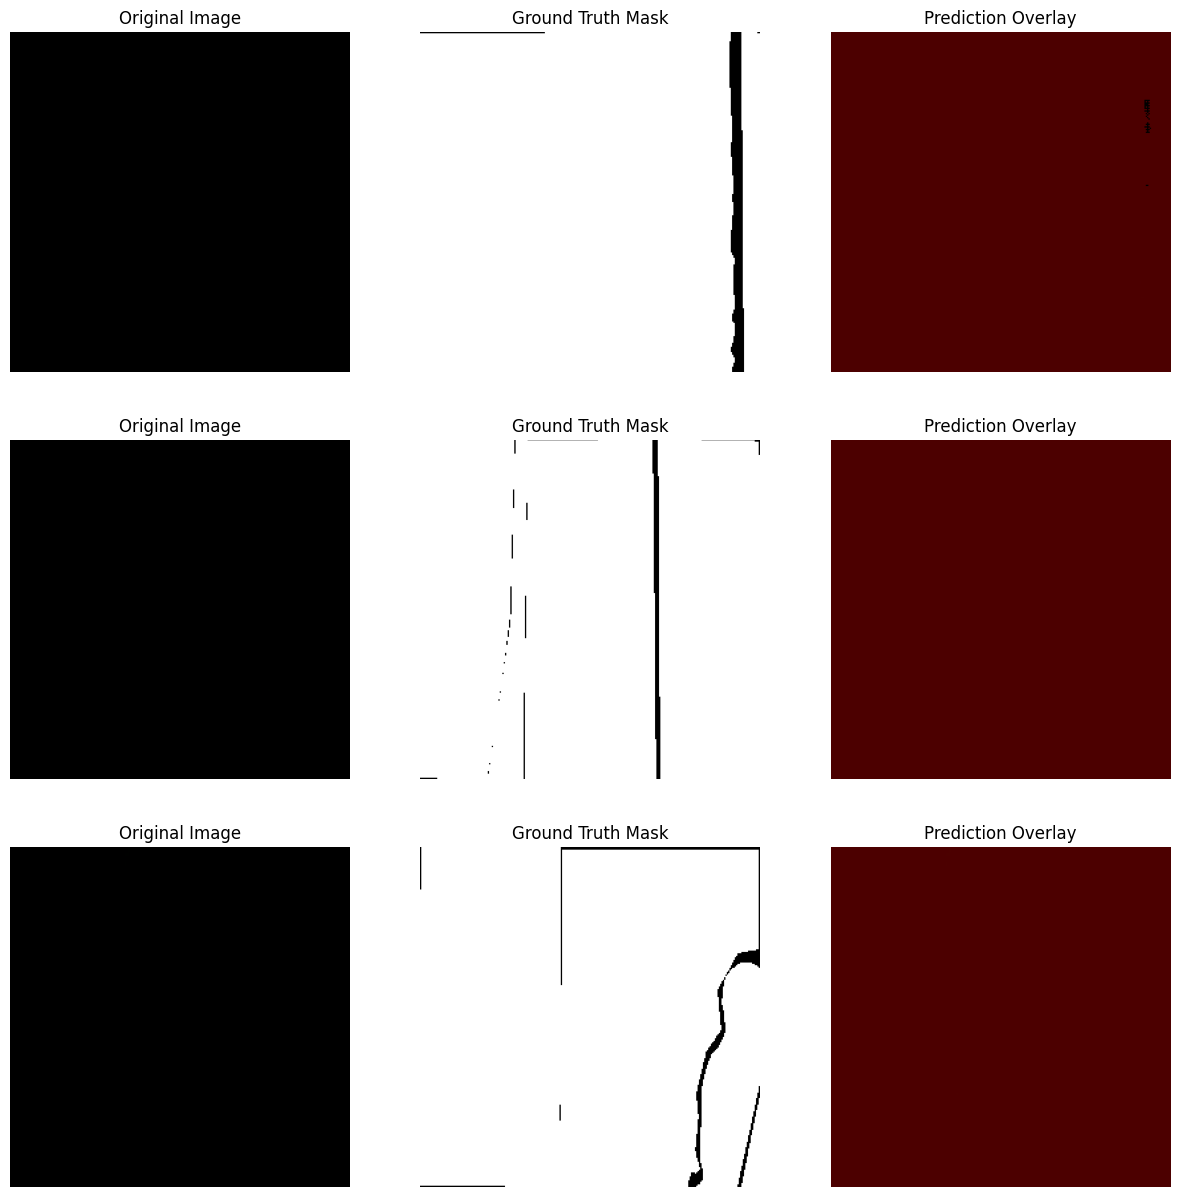

In [40]:
def visualize_predictions_overlay(model, dataset, num_samples=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)

        plt.figure(figsize=(15, num_samples*5))
        for i in range(num_samples):
            img = images[i].numpy().astype("uint8")
            true_mask = masks[i].numpy().squeeze()
            pred_mask = (preds[i] > 0.5).astype("uint8").squeeze()

            # Overlay prediction (red) on original image
            overlay = img.copy()
            overlay[pred_mask == 1] = [255, 0, 0]  # red for spill
            blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

            # Show results
            plt.subplot(num_samples, 3, i*3+1)
            plt.imshow(img)
            plt.title("Original Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+2)
            plt.imshow(true_mask, cmap="gray")
            plt.title("Ground Truth Mask")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3+3)
            plt.imshow(blended)
            plt.title("Prediction Overlay")
            plt.axis("off")
        plt.show()

# Call function
visualize_predictions_overlay(model, test_dataset, num_samples=3)
